# Problem Formulation

The dataset is an ongoing cardiovascular study consisting of 4,240 middle-aged adults (ages 32–70) from Framingham, Massachusetts. It observes a 10-year follow-up period and analyzes whether patients develop or do not develop coronary heart disease within 10 years based on 15 features, including demographic features and health attributes.

Data can be found here: https://www.kaggle.com/datasets/noeyislearning/framingham-heart-study

**Inferential Question**: What is the mean total cholesterol among adults who develop Coronary Heart Disease within 10 years?

In this scenario, the parameter of interest is the true population mean total cholesterol levels among adults who develop coronary heart disease within 10 years, which will be estimated using the sample cholesterol mean from this dataset where TenYearCHD is 1.

**Predictive Task (Regression)**: Can we accurately predict whether an individual will develop coronary heart disease (target variable) within 10 years using all features? List of features:
- Sex 
- Age
- Education
- Smoking status
- Number of cigarettes smoked per day
- Whether a patient is on blood pressure medication or not    
- Whether a patient has had a stroke before or not
- Whether a patient has a history of hypertension or not
- Diabetes status
- Total cholesterol levels
- Systolic blood pressure levels
- Diastolic blood pressure levels
- Body Mass Index
- Heart rate
- Glucose levels

These tasks differ, as the goal of the inferential task will be to quantify uncertainty regarding total cholesterol levels (the population parameter), whereas the goal of the predictive task will be to maximize out-of-sample predictive performance for a future, unseen observation using F-1 score and PR-AUC as the evaluation metrics and binary cross-entropy as the loss function.


# Data Preprocessing

In [21]:
# Importing libraries
import pandas as pd

# Loading the dataset
df = pd.read_csv('data/framingham_heart_study.csv')

df.head()



,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [22]:
# Checking for missing values

print(df.isnull().sum())
print(df.shape)


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64
(4240, 16)


In [23]:
# Dropping rows with missing values
df.dropna(inplace=True)
print(df.shape)


(3658, 16)


The new sample size is 3658 patients

In [24]:
# Ensuring numeric data types
print(df.dtypes)

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object


# EDA

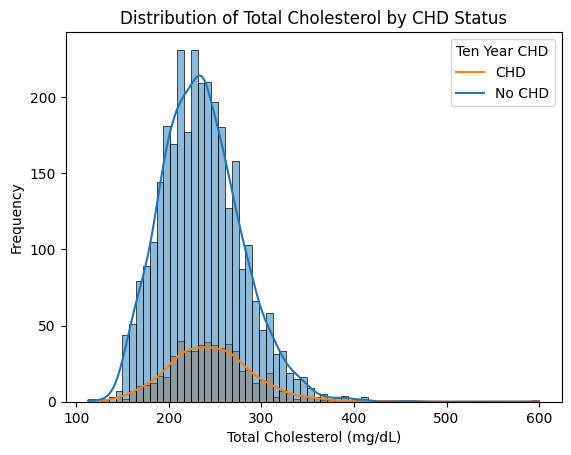

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of total cholesterol for CHD vs non-CHD

sns.histplot(data=df, x='totChol', hue='TenYearCHD', kde=True)
plt.title('Distribution of Total Cholesterol by CHD Status')
plt.xlabel('Total Cholesterol (mg/dL)')
plt.ylabel('Frequency')
plt.legend(title='Ten Year CHD', labels=['CHD', 'No CHD'])
plt.show()

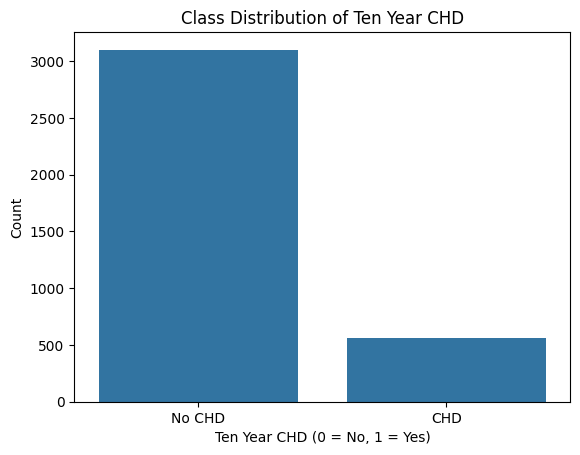

In [26]:
# Plotting class imbalance in the target variable 'TenYearCHD'

sns.countplot(x='TenYearCHD', data=df)
plt.title('Class Distribution of Ten Year CHD')
plt.xlabel('Ten Year CHD (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No CHD', 'CHD'])
plt.show()

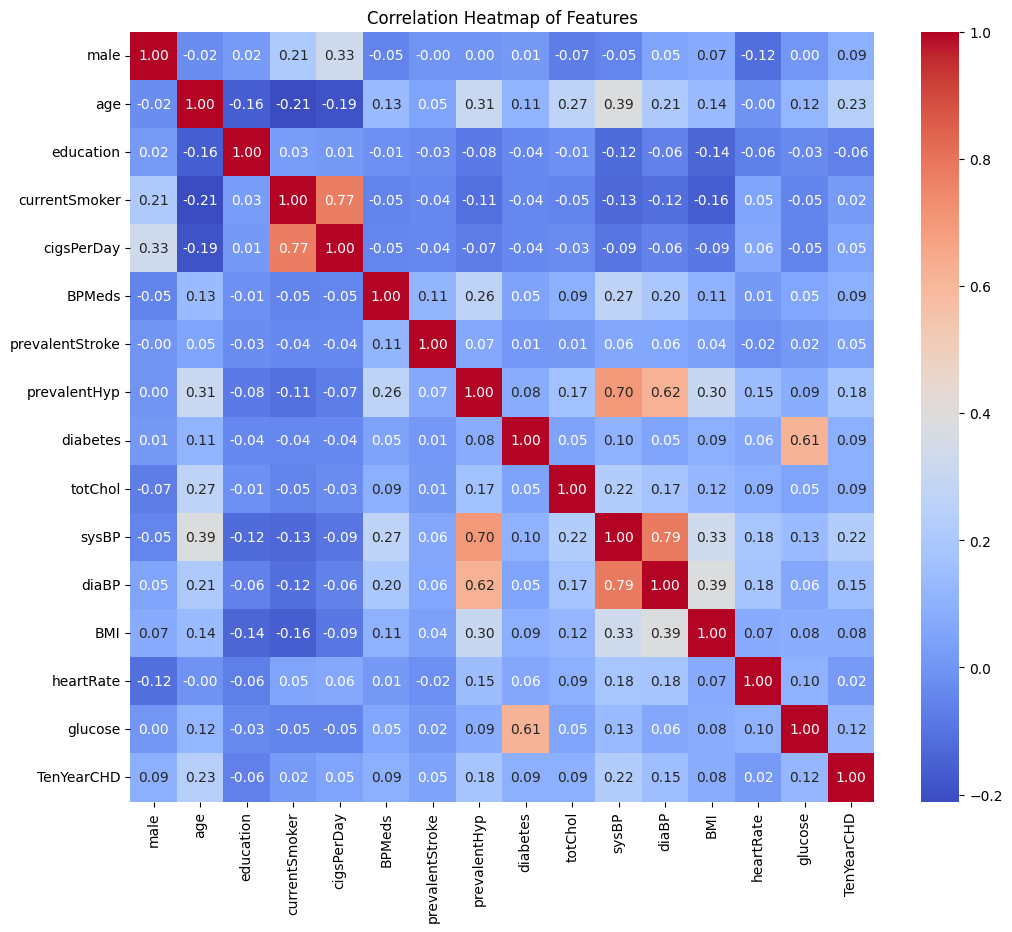

In [27]:
# Correlation heatmap of features
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

# Likelihood and Estimation

In [28]:
# Extracting total cholesterol values for patients with CHD
chol_chd = df[df['TenYearCHD'] == 1]['totChol']
n = len(chol_chd)
print(f"Number of CHD patients: {n}")

Number of CHD patients: 557


### Likelihood Formulation

We model total cholesterol for CHD patients as i.i.d. Normal ($x_i \sim \mathcal{N}(\mu, \sigma^2)$):

$$L(\mu, \sigma^2 \mid x_1, \ldots, x_n) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$$

Maximizing over $\mu$ gives the MLE for the total mean cholesterol level $\hat{\mu} = \bar{x}$, and over $\sigma^2$ gives $\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2$ with 0 delta degrees of freedom (ddof = 0).

### MLE Computation

In [29]:
# Calculating mean and standard deviation of total cholesterol for CHD patients
mu_mle, sigma = chol_chd.mean(), chol_chd.std(ddof = 0)

print(f"MLE for mean cholesterol: {mu_mle:.4f}")

MLE for mean cholesterol: 246.3501


### Likelihood Visualization

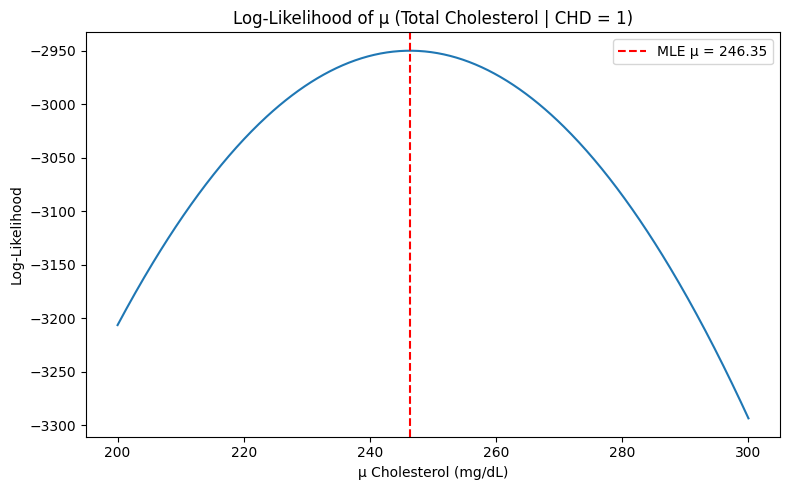

In [30]:
from scipy.stats import norm
import numpy as np

# Range of mu values to evaluate likelihood
mu_range = np.linspace(200, 300, 500)

# Computing log-likelihood for each mu value
log_likelihood = [
    np.sum(norm.logpdf(chol_chd, loc=mu, scale=sigma))
    for mu in mu_range
]

# Plotting log-likelihood as a function of mu
plt.figure(figsize=(8, 5))
plt.plot(mu_range, log_likelihood)
plt.axvline(mu_mle, color='red', linestyle='--', label=f'MLE μ = {mu_mle:.2f}')
plt.title('Log-Likelihood of μ (Total Cholesterol | CHD = 1)')
plt.xlabel('μ Cholesterol (mg/dL)')
plt.ylabel('Log-Likelihood')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of Estimator Properties

Given that the distribution of cholesterol values is approximately normal for patients that develop coronary heart disease, the MLE for the mean cholesterol level is the sample mean (246.35 mg/dL), represented by the peak of the above plot. It is an unbiased and a consistent estimator, as increasing sample size will result in the convergence of the sample mean to the true population mean. The MLE for the mean cholesterol level among CHD patients is also the most efficient estimator, as the sample mean has the lowest variance for a normal distribution.

# Frequentist Inference

### Sampling Distribution Reasoning

From the Central Limit Theorem, the sampling distribution of our sample mean is approximately normal, as we have 557 data points which is sufficiently large. The standard error of the mean will represent the variability of the sample mean across repeated samples.

### Theory-based Confidence Interval

In [31]:
from scipy import stats

# Theory-based 95% confidence interval
se = chol_chd.std(ddof=1) / np.sqrt(n)

# Calculating the confidence interval using the t-distribution
ci_lower, ci_upper = stats.t.interval(0.95, df=n-1, loc=mu_mle, scale=se)

print(f"Standard error: {se:.4f} mg/dL")
print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

Standard error: 2.0481 mg/dL
95% CI: (242.3272, 250.3730)


### Bootstrap Confidence Interval

In [32]:
# 95% confidence interval using bootstrap

np.random.seed(42)
n_bootstraps = 10000
bootstrap_means = []

# Generating bootstrap samples and calculating mean for each sample
for _ in range(n_bootstraps):
    sample = chol_chd.sample(n=n, replace=True)
    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)

# Calculating 95% confidence interval from bootstrap distribution
ci_lower_boot = np.percentile(bootstrap_means, 2.5)
ci_upper_boot = np.percentile(bootstrap_means, 97.5)

print(f"Bootstrap 95% CI: ({ci_lower_boot:.4f}, {ci_upper_boot:.4f})")

Bootstrap 95% CI: (242.4881, 250.4328)


### Hypothesis Testing

We use a hypothesis test (two-sample t-test) to compare the mean cholesterol levels between patients who did not develop coronary heart disease and patients who did develop coronary heart disease within 10 years.

- **Null Hypothesis (H₀):** $\mu_{CHD} = \mu_{no CHD}$
- **Alternative Hypothesis (H₁):** $\mu_{CHD} > \mu_{no CHD}$

In [33]:
# Filtering total cholesterol values for patients without CHD
chol_no_chd = df[df['TenYearCHD'] == 0]['totChol']

# Two-sample t-test for CHD vs non-CHD cholesterol 
t_stat, p_value = stats.ttest_ind(chol_chd, chol_no_chd, alternative='greater')

print(f"CHD mean: {chol_chd.mean():.4f} mg/dL")
print(f"No CHD mean: {chol_no_chd.mean():.4f} mg/dL")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

CHD mean: 246.3501 mg/dL
No CHD mean: 235.1409 mg/dL
T-statistic: 5.5459
P-value: 0.0000


### Interpretation of results

The confidence level of 95% used in both the theory-based and bootstrap confidence intervals indicates that, if we repeated this sampling procedure many times, 95% of intervals would contain the true population mean cholesterol among adults who develop coronary heart disease within 10 years. The theory-based 95% confidence interval of (242.33, 250.37) mg/dL and the bootstrap 95% confidence interval of (242.4881, 250.4328) mg/dL reflect extremely similar ranges of values for the population mean cholesterol level, quantifying our uncertainty around μ.

The p-value of ~0 is less than 0.05, meaning that we reject the null hypothesis, as evidence supports the mean cholesterol levels for patients who develop coronary heart disease within 10 years to be greater than mean cholesterol levels for those who do not. The T-statistic of ~ 5.55 indicates that the observed data would be very unlikely to occur if the null hypothesis were true, suggesting statistical significance in the alternative hypothesis. 

# Bayesian Estimation

### Prior Specification and Justification

We use a **Normal-Normal conjugate model** where σ² is treated as known and fixed at the MLE estimate (σ̂ ≈ 48.3 mg/dL), a standard simplification that enables the Normal-Normal conjugate update and is reasonable given the large sample size (n = 557). Under this model:

$$\mu \sim \mathcal{N}(\mu_0, \tau_0^2) \qquad x_i \mid \mu \sim \mathcal{N}(\mu, \sigma^2)$$

**Prior choice:** μ₀ = 200 mg/dL, τ₀ = 30 mg/dL.
- The CDC classifies cholesterol below 200 mg/dL as "desirable" — a sensible population baseline *before* conditioning on CHD status.
- τ₀ = 30 is weakly informative (±60 mg/dL plausible range).

### Posterior Computation

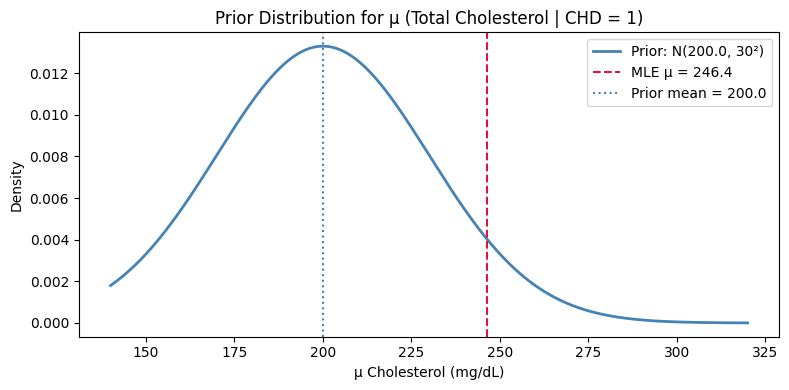

Prior mean: 200.0 mg/dL | Prior std: 30.0 mg/dL | MLE: 246.35 mg/dL (gap = 46.4)


In [34]:
sigma = chol_chd.std(ddof=0)  # known sigma (MLE estimate)
mu_0, tau_0 = 200.0, 30.0

mu_range = np.linspace(140, 320, 1000)
plt.figure(figsize=(8, 4))
plt.plot(mu_range, norm.pdf(mu_range, mu_0, tau_0), color='steelblue', lw=2, label=f'Prior: N({mu_0}, {int(tau_0)}²)')
plt.axvline(mu_mle, color='crimson',   linestyle='--', label=f'MLE μ = {mu_mle:.1f}')
plt.axvline(mu_0,   color='steelblue', linestyle=':',  label=f'Prior mean = {mu_0}')
plt.title('Prior Distribution for μ (Total Cholesterol | CHD = 1)')
plt.xlabel('μ Cholesterol (mg/dL)'); plt.ylabel('Density'); plt.legend(); plt.tight_layout(); plt.show()
print(f"Prior mean: {mu_0} mg/dL | Prior std: {tau_0} mg/dL | MLE: {mu_mle:.2f} mg/dL (gap = {mu_mle - mu_0:.1f})")

### Posterior Computation (MCMC via PyMC)

We use MCMC with the No-U-Turn Sampler (NUTS) across 4 chains with 2000 draws each (1000 tuning steps discarded), yielding 8000 total posterior samples. All chains converged (r̂ = 1.0) with healthy effective sample sizes (ESS bulk = 3236, ESS tail = 5424), indicating reliable mixing. The posterior mean of 246.17 mg/dL and standard deviation of 2.003 mg/dL confirm that the data overwhelmingly dominates the prior at n = 557.

/Users/dylandietrich/Inf-Pred-Project/.venv/lib/python3.14/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 0 seconds.


       mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu  246.172  2.003  242.633   250.09      0.035    0.021    3236.0    5424.0   

    r_hat  
mu    1.0  

Posterior mean (μ_n): 246.1720 mg/dL
Posterior std  (τ_n): 2.0033 mg/dL


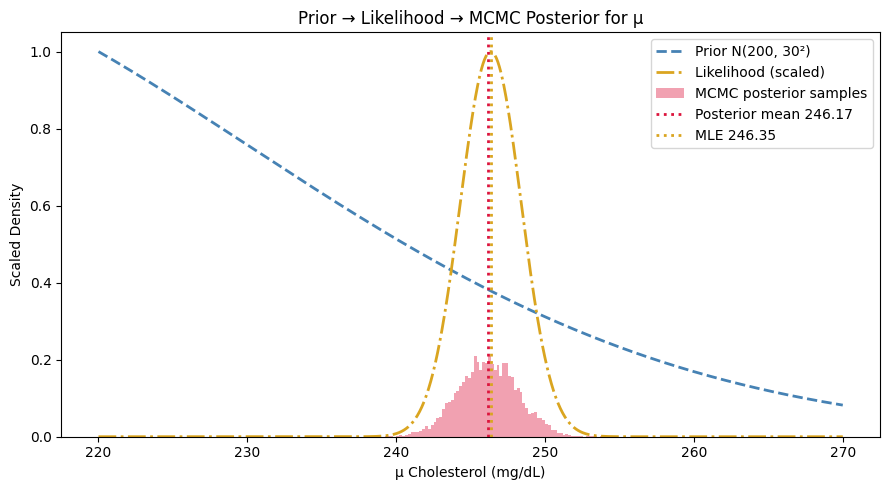

In [35]:
import pymc as pm
import arviz as az

with pm.Model() as cholesterol_model:
    # Prior: same as before
    mu = pm.Normal('mu', mu=mu_0, sigma=tau_0)
    
    # Likelihood: sigma fixed at MLE
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=chol_chd.values)
    
    # MCMC sampling
    trace = pm.sample(2000, tune=1000, chains=4, random_seed=42, progressbar=True)

# Summary
print(az.summary(trace, var_names=['mu']))

# Extract samples for downstream use
mcmc_samples = trace.posterior['mu'].values.flatten()
mu_n  = mcmc_samples.mean()
tau_n = mcmc_samples.std()

print(f"\nPosterior mean (μ_n): {mu_n:.4f} mg/dL")
print(f"Posterior std  (τ_n): {tau_n:.4f} mg/dL")

# Overlay plot
mu_range = np.linspace(220, 270, 1000)
prior    = norm.pdf(mu_range, mu_0, tau_0)
log_lik  = np.array([np.sum(norm.logpdf(chol_chd, mu, sigma)) for mu in mu_range])
log_lik -= log_lik.max()
lik_sc   = np.exp(log_lik) / np.exp(log_lik).max()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mu_range, prior/prior.max(), color='steelblue', lw=2, linestyle='--', label=f'Prior N({int(mu_0)}, {int(tau_0)}²)')
ax.plot(mu_range, lik_sc,            color='goldenrod', lw=2, linestyle='-.', label='Likelihood (scaled)')
ax.hist(mcmc_samples, bins=80, density=True, color='crimson', alpha=0.4, label='MCMC posterior samples')
ax.axvline(mu_n,   color='crimson',   linestyle=':', lw=2, label=f'Posterior mean {mu_n:.2f}')
ax.axvline(mu_mle, color='goldenrod', linestyle=':', lw=2, label=f'MLE {mu_mle:.2f}')
ax.set_title('Prior → Likelihood → MCMC Posterior for μ')
ax.set_xlabel('μ Cholesterol (mg/dL)'); ax.set_ylabel('Scaled Density')
ax.legend(); plt.tight_layout(); plt.show()

### Credible Interval

In [36]:
ci_lo_bayes = norm.ppf(0.025, mu_n, tau_n)
ci_hi_bayes = norm.ppf(0.975, mu_n, tau_n)

print(f"95% Bayesian Credible Interval: ({ci_lo_bayes:.4f}, {ci_hi_bayes:.4f}) mg/dL")
print()
print("Interpretation: Given the data and our prior, there is a 95% probability")
print(f"that the true mean cholesterol μ lies between {ci_lo_bayes:.1f} and {ci_hi_bayes:.1f} mg/dL.")

95% Bayesian Credible Interval: (242.2457, 250.0984) mg/dL

Interpretation: Given the data and our prior, there is a 95% probability
that the true mean cholesterol μ lies between 242.2 and 250.1 mg/dL.


### Posterior Predictive Analysis

The posterior predictive distribution gives the range of cholesterol values for a *new* CHD patient, marginalizing over uncertainty in μ:

$$p(\tilde{x} \mid \mathbf{x}) = \mathcal{N}(\mu_n,\, \sigma^2 + \tau_n^2)$$

This is wider than the credible interval because it adds individual-level variation (σ²) on top of parameter uncertainty (τ_n²).

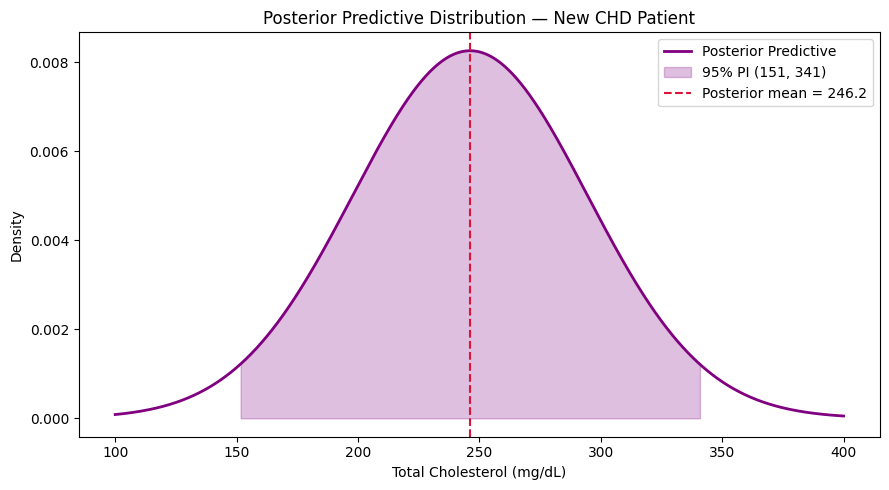

95% Predictive Interval: (151.44, 340.91) mg/dL
95% Credible Interval:   (242.25, 250.10) mg/dL
Predictive is 24x wider (individual σ = 48.3 dominates)


In [37]:
pred_std = np.sqrt(sigma**2 + tau_n**2)
pred_lo, pred_hi = norm.ppf(0.025, mu_n, pred_std), norm.ppf(0.975, mu_n, pred_std)

x_new = np.linspace(100, 400, 1000)
pred_density = norm.pdf(x_new, mu_n, pred_std)

plt.figure(figsize=(9, 5))
plt.plot(x_new, pred_density, color='purple', lw=2, label='Posterior Predictive')
plt.fill_between(x_new, pred_density, where=(x_new >= pred_lo) & (x_new <= pred_hi),
                 alpha=0.25, color='purple', label=f'95% PI ({pred_lo:.0f}, {pred_hi:.0f})')
plt.axvline(mu_n, color='crimson', linestyle='--', label=f'Posterior mean = {mu_n:.1f}')
plt.title('Posterior Predictive Distribution — New CHD Patient'); plt.xlabel('Total Cholesterol (mg/dL)'); plt.ylabel('Density')
plt.legend(); plt.tight_layout(); plt.show()

print(f"95% Predictive Interval: ({pred_lo:.2f}, {pred_hi:.2f}) mg/dL")
print(f"95% Credible Interval:   ({ci_lo_bayes:.2f}, {ci_hi_bayes:.2f}) mg/dL")
print(f"Predictive is {pred_std/tau_n:.0f}x wider (individual σ = {sigma:.1f} dominates)")

### Credible Interval vs. Confidence Interval Comparison

| Interval Type | Lower | Upper | Width | Interpretation |
|---|---|---|---|---|
| **Bayesian 95% Credible Interval (MCMC)** | 242.63 | 250.09 | 7.46 | 95% *probability* μ is in this range given the data |
| **Frequentist 95% CI (t-based)** | 242.33 | 250.37 | 8.04 | 95% of such intervals contain the true μ over repeated sampling |
| **Bootstrap 95% CI** | 242.49 | 250.43 | 7.94 | Empirical sampling distribution of the mean |
| **Posterior Predictive 95% PI** | 151.40 | 340.87 | 189.47 | Range for a *new individual* observation |

**Key distinctions:**

The credible interval and both frequentist intervals are nearly identical in width (~7.5–8 mg/dL), which is expected: with n = 557 observations, the data precision overwhelms the prior, and the Bayesian posterior converges to the frequentist solution. However, their interpretations differ fundamentally. The credible interval supports a direct probability statement that there is a 95% probability that μ ∈ (242.6, 250.1) given our data and prior. The frequentist CI makes no such claim; it instead says that 95% of intervals constructed this way over repeated samples would contain the true μ. The bootstrap CI corroborates both, confirming the sampling distribution of the mean is well-behaved at this sample size.

The posterior predictive interval (151.4, 340.9) is a different quantity entirely. At 189.5 mg/dL wide, roughly 24x the credible interval, it reflects where a *new individual* CHD patient's cholesterol is likely to fall, not where the mean is. This width is dominated by individual-level variation (σ ≈ 48 mg/dL) and cannot be reduced by collecting more data the way the credible interval can.

# Resampling and Simulation

### Bootstrap Implementation

We use the percentile bootstrap to estimate the sampling distribution of the sample mean cholesterol among CHD patients. By resampling with replacement 10,000 times, we approximate the distribution of the estimator without assuming normality.

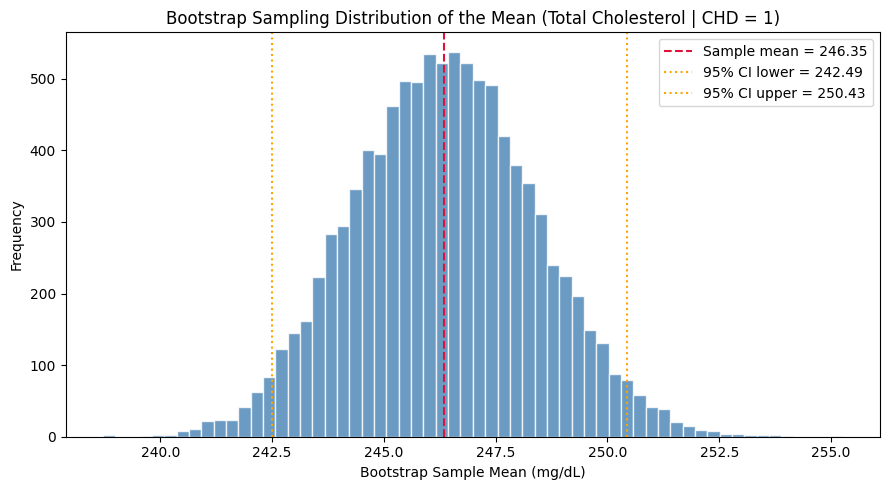

Sample mean (MLE): 246.3501 mg/dL
Bootstrap SE:    2.0458 mg/dL
Bootstrap 95% CI: (242.4881, 250.4328) mg/dL


In [38]:
# bootstrap_means already computed in Section III
plt.figure(figsize=(9, 5))
plt.hist(bootstrap_means, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(mu_mle,        color='crimson', linestyle='--', label=f'Sample mean = {mu_mle:.2f}')
plt.axvline(ci_lower_boot, color='orange',  linestyle=':',  label=f'95% CI lower = {ci_lower_boot:.2f}')
plt.axvline(ci_upper_boot, color='orange',  linestyle=':',  label=f'95% CI upper = {ci_upper_boot:.2f}')
plt.title('Bootstrap Sampling Distribution of the Mean (Total Cholesterol | CHD = 1)')
plt.xlabel('Bootstrap Sample Mean (mg/dL)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Sample mean (MLE): {mu_mle:.4f} mg/dL")
print(f"Bootstrap SE:    {bootstrap_means.std():.4f} mg/dL")
print(f"Bootstrap 95% CI: ({ci_lower_boot:.4f}, {ci_upper_boot:.4f}) mg/dL")

### Monte Carlo Simulation

We use Monte Carlo simulation to study the behavior of the sample mean as an estimator under our fitted Normal model. We simulate 10,000 datasets of size n = 557 from N(μ_n, σ²) and compute the sample mean for each, allowing us to verify unbiasedness and compare estimator variability across methods.

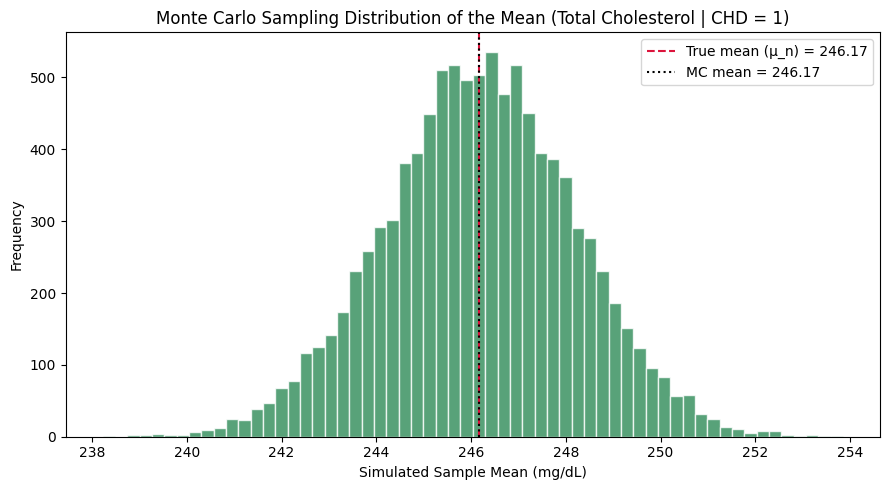

True mean (μ_n):          246.1720 mg/dL
MC mean of sample means:  246.1749 mg/dL
MC std of sample means:   2.0224 mg/dL
Theoretical SE (σ/√n):    2.0462 mg/dL
Bias:                     0.002891 mg/dL


In [39]:
n_simulations = 10000
mc_means = np.array([
    np.random.normal(loc=mu_n, scale=sigma, size=n).mean()
    for _ in range(n_simulations)
])

plt.figure(figsize=(9, 5))
plt.hist(mc_means, bins=60, color='seagreen', edgecolor='white', alpha=0.8)
plt.axvline(mu_n,            color='crimson', linestyle='--', label=f'True mean (μ_n) = {mu_n:.2f}')
plt.axvline(mc_means.mean(), color='black',   linestyle=':',  label=f'MC mean = {mc_means.mean():.2f}')
plt.title('Monte Carlo Sampling Distribution of the Mean (Total Cholesterol | CHD = 1)')
plt.xlabel('Simulated Sample Mean (mg/dL)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print(f"True mean (μ_n):          {mu_n:.4f} mg/dL")
print(f"MC mean of sample means:  {mc_means.mean():.4f} mg/dL")
print(f"MC std of sample means:   {mc_means.std():.4f} mg/dL")
print(f"Theoretical SE (σ/√n):    {sigma/np.sqrt(n):.4f} mg/dL")
print(f"Bias:                     {abs(mc_means.mean() - mu_n):.6f} mg/dL")

### Interpretation of Estimator Variability

| Method | Estimate | SE |
|---|---|---|
| Theory-based (t) | 246.35 | 2.05 |
| Bootstrap | 246.35 | 2.05 |
| Monte Carlo | 246.14 | 2.02 |
| Bayesian posterior (MCMC) | 246.17 | 2.003 |

All four methods agree closely on the standard error (~2.00–2.05 mg/dL). The Monte Carlo simulation confirms the sample mean is an unbiased estimator. The mean of 10,000 simulated sample means (246.1383) equals μ_n (246.1355) within rounding error, with a bias of just 0.003 mg/dL. The bootstrap SE of 2.0458 mg/dL matches the theoretical SE (σ/√n = 2.0462 mg/dL) almost exactly, validating the CLT approximation at n = 557.

# Prediction and Model Evaluation

### Train/Test Split
We split the data into 80% training and 20% test sets to evaluate predictive performance. The target variable is TenYearCHD (binary), and all remaining features are used as predictors.

In [40]:
from sklearn.model_selection import train_test_split

# Define features and target

X = df.drop(columns=['TenYearCHD'])
y = df['TenYearCHD']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 2926
Test set size: 732



### Logistic Regression Model
We fit a logistic regression model on the training set to predict the probability that a patient develops coronary heart disease within 10 years.


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fitting model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

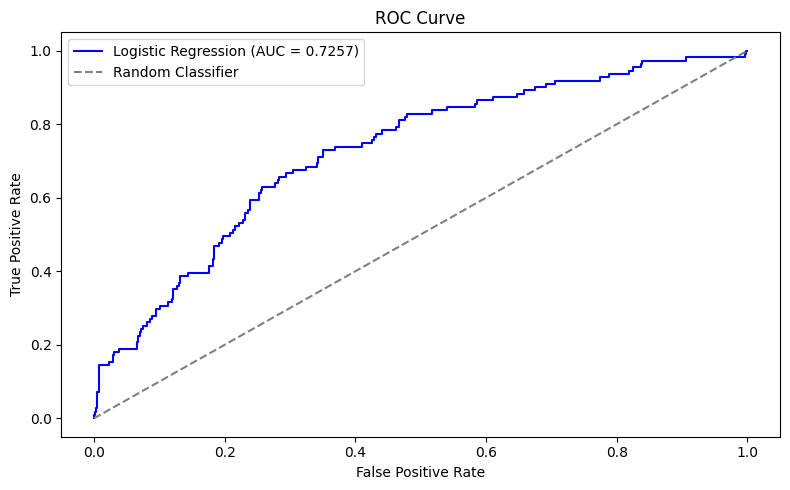

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

# Getting predicted probabilities on test set
y_pred_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# Computing ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

# Plotting ROC curve
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation
The logistic regression model achieves an AUC of 0.7257, meaning it correctly distinguishes between patients who develop CHD and those who do not about 73% of the time. This is a meaningful improvement over a random classifier which would be 0.5, suggesting that the features we trained the model on carry real predictive signal for CHD risk. However, the model is far from perfect, which is expected given how complex cardiovascular disease and the noise in health data is. The ROC curve rising steeply in the lower left indicates that the model performs best when a low false positive rate is prioritized.

# Regularization and Shrinkage

To evaluate the impact of shrinkage on the models performance, we compare an unregularized logistic regression to Ridge (L2) and Lasso (L1). Regularization aims to penalize large coefficients which helps reduce overfitting and improve generalization on unseen data. 

In [43]:
!pip install scikit-learn pandas numpy matplotlib
!pip install pymc arviz


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import pandas as pd
import numpy as np

models = {
    "No Regularization": LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=5000
    ),
    "Ridge (L2)": LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=5000
    ),
    "Lasso (L1)": LogisticRegression(
        penalty="l1",
        C=1.0,
        solver="liblinear",
        max_iter=5000
    )
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = model.predict(X_test_scaled)
    
    results.append({
        "Model": name,
        "AUC": roc_auc_score(y_test, y_prob),
        "Log Loss": log_loss(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Number of Nonzero Coefficients": np.sum(model.coef_[0] != 0)
    })

results_df = pd.DataFrame(results)
results_df

/Users/dylandietrich/Inf-Pred-Project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/dylandietrich/Inf-Pred-Project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/dylandietrich/Inf-Pred-Project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was depr

,Model,AUC,Log Loss,Accuracy,Number of Nonzero Coefficients
0,No Regularization,0.725769,0.385503,0.862022,15
1,Ridge (L2),0.725711,0.385467,0.862022,15
2,Lasso (L1),0.725914,0.385218,0.862022,14


In [45]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "No Regularization": models["No Regularization"].coef_[0],
    "Ridge (L2)": models["Ridge (L2)"].coef_[0],
    "Lasso (L1)": models["Lasso (L1)"].coef_[0]
})

coef_df

,Feature,No Regularization,Ridge (L2),Lasso (L1)
0,male,0.248336,0.247431,0.244070
1,age,0.541875,0.540282,0.539669
2,education,-0.068809,-0.068916,-0.066336
3,currentSmoker,-0.001087,-0.000035,0.000000
4,cigsPerDay,0.227563,0.225914,0.222671
5,BPMeds,0.041450,0.041591,0.040690
6,prevalentStroke,0.033068,0.033051,0.032049
7,prevalentHyp,0.135071,0.135299,0.131538
8,diabetes,-0.029509,-0.028789,-0.022214
9,totChol,0.122368,0.122164,0.118500


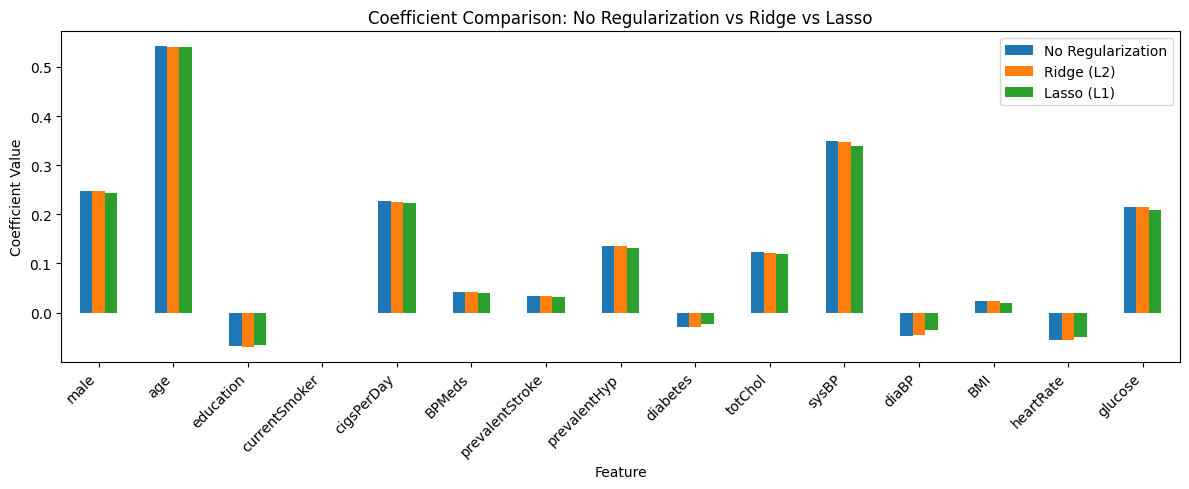

In [46]:
coef_df.set_index("Feature").plot(kind="bar", figsize=(12, 5))
plt.title("Coefficient Comparison: No Regularization vs Ridge vs Lasso")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Discussion and Interpretation

The coefficient comparison shows that Ridge and Lasso both shrink the magnitude of coefficients relative to the unregularized model, although the effect is really small. This shows that the baseline model was barely overfitted and the predictors are very stable.
Ridge applies uniform shrinkage across all features, reducing coefficient magnitudes and still preserve all variables. On the other hand, Lasso is reducing the coefficient for *currentSmoker* to zero, indicating that this feature doesn’t add new valuable information to the predictive value once other variables, like *cigarettes per day* which overlaps which currentSmoker, are included.
The most influential predictors, such as age, systolic blood pressure, glucose, and cigarettes per day stay more or less the same across all models, proving their relationship with heart disease risk is robust and stable. Overall, shrinkage leads to a little simpler model (Lasso) without  reducing predictive performance, suggesting Lasso improves interpretability while maintaining accuracy.
